## Conclusion: Adding a "zero point" set of boosts at f_phi = 0 makes things worse

In [23]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
import ast
import emcee
import corner
import seaborn as sns
from scipy.stats import qmc

# PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel
import sklearn

In [24]:
print(sklearn.__version__)

1.0.2


## Get the data

In [130]:
# Load the saved array - gives Boost(i = sample point, z, k)
Bk_arr = np.load('Boost.npy')
print(Bk_arr.shape)

(50, 51, 768)


In [131]:
# extract data from text file - gives z and k arrays
txt_arr = np.loadtxt("z_k.txt")

z_arr = np.array(txt_arr.T[0][np.isfinite(txt_arr.T[0])])
k_arr = np.array(txt_arr.T[1])

print(z_arr.shape)
print(k_arr.shape)

(51,)
(768,)


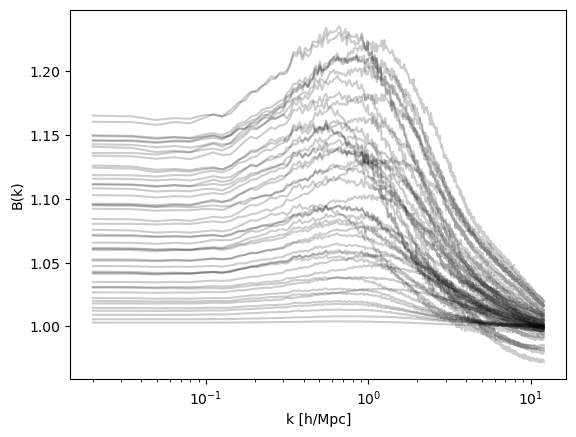

In [132]:
# Plot data

z_index = 12

plt.figure(32)
for sim_index in range(49):
    plt.plot(k_arr, Bk_arr[sim_index, z_index, :], 'k', alpha=0.2)
    

plt.ylabel("B(k)")
plt.xlabel("k [h/Mpc]")
plt.xscale('log')
plt.show()
     


In [133]:
# Get the parameter - for now assume only one parameter, w_m
txt = "cosmo_newdesign.txt"
hcube = np.loadtxt(txt).T
f_phi = hcube[4]
h = hcube[3]
Omega_m = hcube[0]
n_s = hcube[1]
A_s = hcube[2]

theta_1 = np.array([Omega_m,f_phi, h, n_s, A_s])

"""
    wb = 0.0223
    wr = 4.28e-5
"""


'\n    wb = 0.0223\n    wr = 4.28e-5\n'

In [134]:
print(np.argmin(np.abs(f_phi)))
print(f_phi[35])

35
0.02


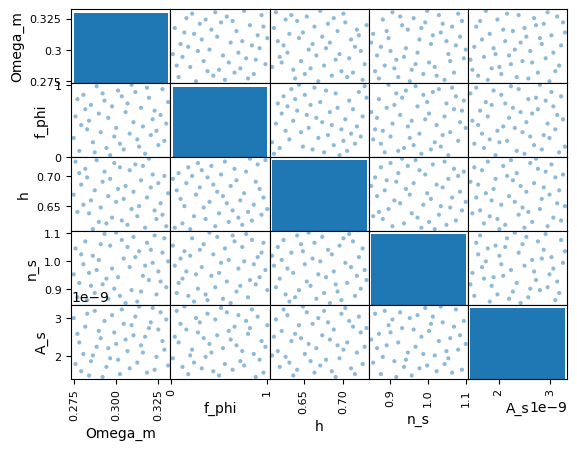

In [135]:
df_theta = pd.DataFrame(theta_1.T, columns=['Omega_m','f_phi', 'h', 'n_s', 'A_s'][:len(theta_1)])
pd.plotting.scatter_matrix(df_theta)
plt.show()


In [136]:
### add zeros at boundary

n_zeros = 5

sampler = qmc.LatinHypercube(4)
sample_val = sampler.random(n=n_zeros).T
theta_zeros = np.insert(sample_val, 1, np.zeros(n_zeros), axis=0)
print(theta_zeros.shape)

Bk_arr_zeros = np.ones((n_zeros,51,768))

(5, 5)


/home/c2042999/anaconda3/envs/MGEmu_env/lib/python3.7/site-packages/pandas/plotting/_matplotlib/misc.py:100: UserWarning: Attempting to set identical left == right == 0.0 results in singular transformations; automatically expanding.
  ax.set_xlim(boundaries_list[j])
/home/c2042999/anaconda3/envs/MGEmu_env/lib/python3.7/site-packages/pandas/plotting/_matplotlib/misc.py:101: UserWarning: Attempting to set identical bottom == top == 0.0 results in singular transformations; automatically expanding.
  ax.set_ylim(boundaries_list[i])
/home/c2042999/anaconda3/envs/MGEmu_env/lib/python3.7/site-packages/pandas/plotting/_matplotlib/misc.py:91: UserWarning: Attempting to set identical left == right == 0.0 results in singular transformations; automatically expanding.
  ax.set_xlim(boundaries_list[i])


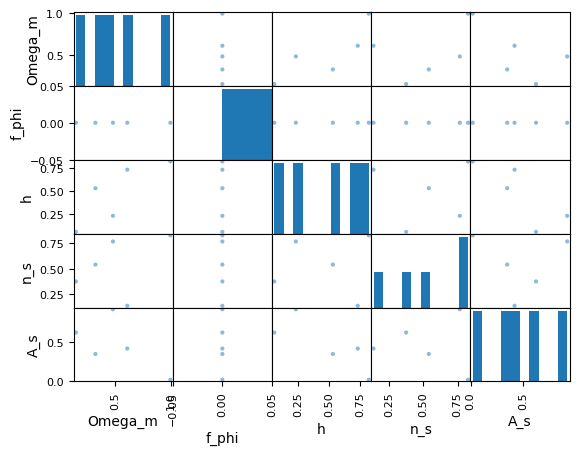

In [137]:
df_theta = pd.DataFrame(theta_zeros.T, columns=['Omega_m','f_phi', 'h', 'n_s', 'A_s'][:len(theta_zeros)])
pd.plotting.scatter_matrix(df_theta)
plt.show()


In [138]:
theta_1 = np.append(theta_1, theta_zeros,axis=1)
print(theta_1.shape)

Bk_arr = np.append(Bk_arr, Bk_arr_zeros,axis=0)

print(Bk_arr.shape)


(5, 55)
(55, 51, 768)


## Create the emulator

In [139]:
"""Trains emulator by finding PCs/optimized hyperparameters for the input data"""

def B_k_emu_init(Bkarr , theta_arr , k , z=0.0):
    """
    Bkarr --> array (n_sim, n_k)theta_arr
    theta_arr --> array (n_param, n_sim)
    k --> array (n_k)
    z --> float (default = 0.0)
    
    returns optimized hyperparameters
    """
    # STEP 1: standardization transformation
    theta = np.zeros((len(theta_arr), len(theta_arr[0])))
    for i in range(len(theta)):
        theta[i] = (theta_arr[i] - np.mean(theta_arr[i]))/np.std(theta_arr[i])
    
    chi = (Bkarr - np.mean(Bkarr, axis=0))/np.std(Bkarr, axis=0)

    # STEP 2: PCA (find components)
    
    Usvd, s, vh = np.linalg.svd(chi.T, full_matrices=True)
    Usvd = Usvd.T
    # only keep idx PCs (contain more than 98% of the information)
    nums = np.arange(6)
    var_ratio = []
    for num in nums:
        pca = PCA(n_components=num)
        pca.fit(chi)
        var_ratio.append(np.sum(pca.explained_variance_ratio_))
    idx = np.argmin(np.abs(var_ratio - np.min([i for i in var_ratio if (i - 0.98) >= 0])))
    idx=3
    print(idx)
    
    # get weights
    w_theta = np.matmul(chi, Usvd[:idx].T)

    # STEP 3: Create and train the Gaussian Process Regressor
    kernel1 =  1.0* Matern(nu=1.5) + WhiteKernel(noise_level=0.1)
    kernel2 =  1.0* Matern(nu=1.5) + WhiteKernel(noise_level=0.1)
    kernel3 =  1.0* Matern(nu=1.5) + WhiteKernel(noise_level=0.1)

    gp1 = GaussianProcessRegressor(kernel=kernel1, n_restarts_optimizer=20)
    gp1.fit(theta.T, w_theta.T[0])
    gp2 = GaussianProcessRegressor(kernel=kernel2, n_restarts_optimizer=20)
    gp2.fit(theta.T, w_theta.T[1])
    gp3 = GaussianProcessRegressor(kernel=kernel3, n_restarts_optimizer=20)
    gp3.fit(theta.T, w_theta.T[2])
    
    return [Bkarr , theta_arr, Usvd, idx, gp1,gp2,gp3]

In [140]:
"""Use the emulator to find the boost at a new set of parameters theta"""

def B_k_emu(init, theta_new_arr):
    """
    Bkarr --> array (n_sim, n_k)
    theta_arr --> array (n_param, n_sim)
    k --> array (n_k)
    z --> float (default = 0.0)
    theta_new_arr --> array (n_param, n_2)
    
    returns Bk_new = Boost(theta_new_arr) --> array (n_2, n_k)
    """
    Bkarr , theta_arr, Usvd, idx, gp1,gp2,gp3 = init
    
    theta_new = np.zeros((len(theta_new_arr), len(theta_new_arr[0])))
    for i in range(len(theta_new)):
        theta_new[i] = (theta_new_arr[i] - np.mean(theta_arr[i]))/np.std(theta_arr[i])
        
    mean2, variance2 = gp1.predict(theta_new.T, return_std=True)
    mean2_2, variance2_2 = gp2.predict(theta_new.T, return_std=True)
    mean2_3, variance2_3 = gp3.predict(theta_new.T, return_std=True)
    print(mean2.shape, mean2_2.shape, mean2_3.shape)
    
    w_theta_emu_arr = np.stack((mean2, mean2_2, mean2_3), axis=1)
    print(w_theta_emu_arr.shape)
    
    Bk_new =(np.matmul(w_theta_emu_arr, Usvd[:idx])*np.std(Bkarr, axis=0) + np.mean(Bkarr, axis=0))

    return Bk_new

In [141]:
init = B_k_emu_init(Bk_arr[:, 0, :] , theta_1 , k_arr , z=0.0)

3


/home/c2042999/anaconda3/envs/MGEmu_env/lib/python3.7/site-packages/sklearn/gaussian_process/kernels.py:427: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  ConvergenceWarning,


## Using the emulator: recover training data

(55,) (55,) (55,)
(55, 3)
(55, 768)


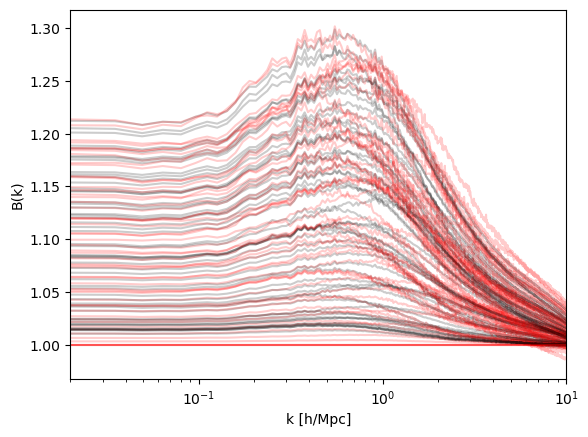

In [142]:
Bk_new = B_k_emu(init, theta_1)
print(Bk_new.shape)
for sim_index in range(len(Bk_new)):
    plt.plot(k_arr, Bk_new[sim_index], 'k', alpha=0.2)
    plt.plot(k_arr, Bk_arr[sim_index, 0, :], 'r', alpha=0.2)

f1 = plt.plot([1,1], [1,1], 'k', alpha=0.2, label="data from emulator")
f2 = plt.plot([1,1], [1,1], 'r', alpha=0.2, label="training dataset")
f1 = f1.pop(0)
f2 = f2.pop(0)

f1.remove()
f2.remove()

plt.ylabel("B(k)")
plt.xlim(2e-2,1e1)

plt.xlabel("k [h/Mpc]")
plt.xscale("log")

## Using the emulator: validation data set 1

In [143]:
# Load the saved array - gives Boost(i = sample point, z, k)
Bk_arr_val = np.load('Validation_data/Boost_validation.npy')
print(Bk_arr_val.shape)
# extract data from text file - gives z and k arrays
txt_arr_val = np.loadtxt("Validation_data/z_k_validation.txt")

z_arr_val = np.array(txt_arr_val.T[0][np.isfinite(txt_arr_val.T[0])])
k_arr_val = np.array(txt_arr_val.T[1])

print(z_arr_val.shape)
print(k_arr_val.shape)

(25, 101, 768)
(101,)
(768,)


In [144]:
# Get the parameter - for now assume only one parameter, w_m
txt = "Validation_data/cosmo_validation.txt"
hcube_val  = np.loadtxt(txt).T
f_phi_val = hcube_val[4]
h_val = hcube_val[3]
Omega_m_val = hcube_val[0]
n_s_val = hcube_val[1]
A_s_val = hcube_val[2]

theta_1_val = np.array([Omega_m_val ,f_phi_val , h_val , n_s_val , A_s_val ])

"""
    wb = 0.0223
    wr = 4.28e-5
"""


'\n    wb = 0.0223\n    wr = 4.28e-5\n'

/home/c2042999/anaconda3/envs/MGEmu_env/lib/python3.7/site-packages/pandas/plotting/_matplotlib/misc.py:91: UserWarning: Attempting to set identical left == right == 0.321 results in singular transformations; automatically expanding.
  ax.set_xlim(boundaries_list[i])
/home/c2042999/anaconda3/envs/MGEmu_env/lib/python3.7/site-packages/pandas/plotting/_matplotlib/misc.py:101: UserWarning: Attempting to set identical bottom == top == 0.321 results in singular transformations; automatically expanding.
  ax.set_ylim(boundaries_list[i])
/home/c2042999/anaconda3/envs/MGEmu_env/lib/python3.7/site-packages/pandas/plotting/_matplotlib/misc.py:100: UserWarning: Attempting to set identical left == right == 0.6688 results in singular transformations; automatically expanding.
  ax.set_xlim(boundaries_list[j])
/home/c2042999/anaconda3/envs/MGEmu_env/lib/python3.7/site-packages/pandas/plotting/_matplotlib/misc.py:100: UserWarning: Attempting to set identical left == right == 0.9626 results in singular

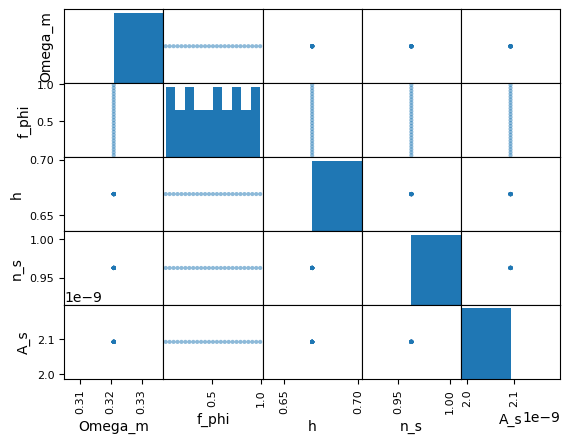

In [145]:
df_theta = pd.DataFrame(theta_1_val.T, columns=['Omega_m','f_phi', 'h', 'n_s', 'A_s'][:len(theta_1_val)])
pd.plotting.scatter_matrix(df_theta)
plt.show()


(25,) (25,) (25,)
(25, 3)


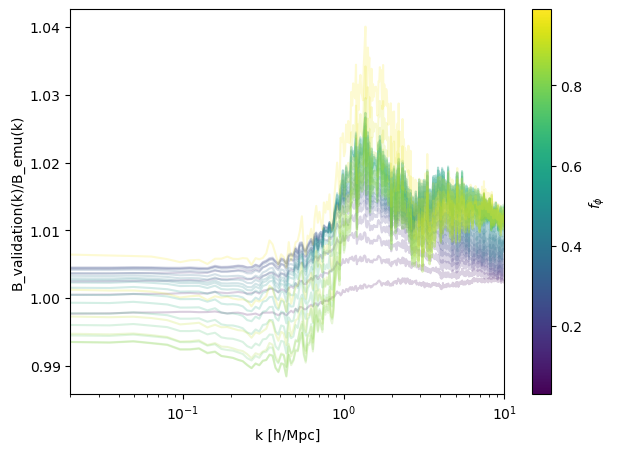

In [146]:
f, ax = plt.subplots(1,figsize=(7, 5))

Bk_test_val = B_k_emu(init, theta_1_val)

cmap = matplotlib.colormaps['viridis']

for sim_index in range(len(Bk_test_val)):
    ax.plot(k_arr, Bk_arr_val[sim_index, 0, :]/Bk_test_val[sim_index],color = cmap(f_phi_val[sim_index]), alpha=0.2)

ax.set_ylabel("B_validation(k)/B_emu(k)")
ax.set_xlim(2e-2,1e1)

norm = matplotlib.colors.Normalize(vmin=min(f_phi_val), vmax=max(f_phi_val))
f.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax = ax, orientation='vertical', label=r'$f_{\phi}$')

ax.set_xlabel("k [h/Mpc]")
ax.set_xscale("log")

## Using the emulator: validation data set 2

In [147]:
# Load the saved array - gives Boost(i = sample point, z, k)
Bk_arr_val_edges = np.load('Validation_data/Boost_validation_edges.npy')
print(Bk_arr_val_edges.shape)
# extract data from text file - gives z and k arrays
txt_arr_val_edges = np.loadtxt("Validation_data/z_k_validation_edges.txt")

z_arr_val_edges = np.array(txt_arr_val_edges.T[0][np.isfinite(txt_arr_val_edges.T[0])])
k_arr_val_edges = np.array(txt_arr_val_edges.T[1])

print(z_arr_val_edges.shape)
print(k_arr_val_edges.shape)

(50, 101, 768)
(101,)
(768,)


In [148]:
# Get the parameter - for now assume only one parameter, w_m
txt = "Validation_data/cosmo_validation_edges"
hcube_val_edges  = np.loadtxt(txt).T
f_phi_val_edges = hcube_val_edges[4]
h_val_edges = hcube_val_edges[3]
Omega_m_val_edges = hcube_val_edges[0]
n_s_val_edges = hcube_val_edges[1]
A_s_val_edges = hcube_val_edges[2]

theta_1_val_edges = np.array([Omega_m_val_edges ,f_phi_val_edges , h_val_edges , n_s_val_edges , A_s_val_edges ])

"""
    wb = 0.0223
    wr = 4.28e-5
"""


'\n    wb = 0.0223\n    wr = 4.28e-5\n'

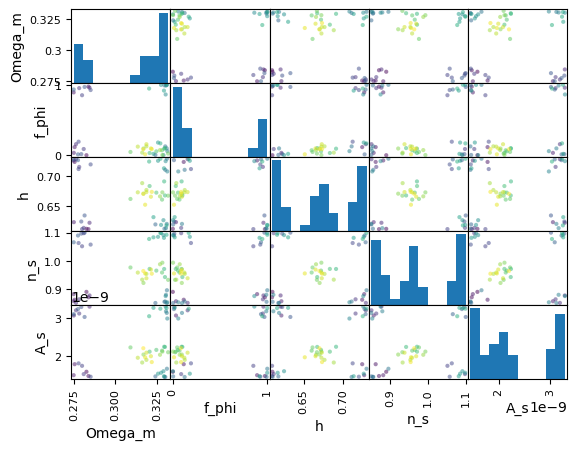

In [149]:
df_theta = pd.DataFrame(theta_1_val_edges.T, columns=['Omega_m','f_phi', 'h', 'n_s', 'A_s'][:len(theta_1_val_edges)])
pd.plotting.scatter_matrix(df_theta, color = cmap(np.linspace(0,1,len(f_phi_val_edges))))
plt.show()


(50,) (50,) (50,)
(50, 3)


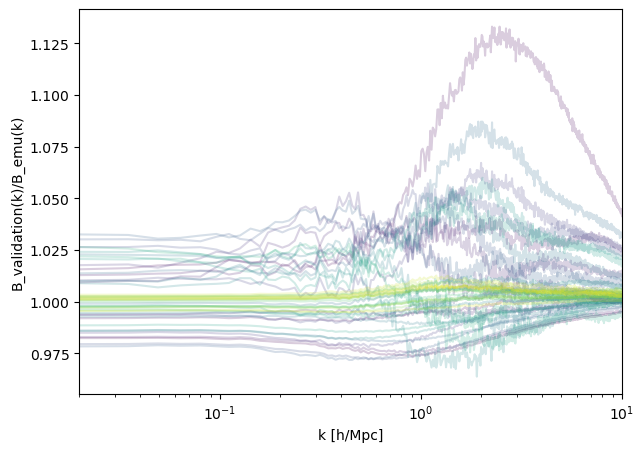

In [150]:
f, ax = plt.subplots(1,figsize=(7, 5))

Bk_test_val_edges = B_k_emu(init, theta_1_val_edges)

cmap = matplotlib.colormaps['viridis']

for sim_index in range(len(Bk_arr_val_edges)):
    ax.plot(k_arr, Bk_arr_val_edges[sim_index, 0, :]/Bk_test_val_edges[sim_index],color = cmap(np.linspace(0,1,len(f_phi_val_edges))[sim_index]), alpha=0.2)

ax.set_ylabel("B_validation(k)/B_emu(k)")
ax.set_xlim(2e-2,1e1)

ax.set_xlabel("k [h/Mpc]")
ax.set_xscale("log")

## Sensitivity analysis from the emulator 

In [326]:
# For each of the parameters, we fix all other parameters to some fiducial values and vary the one parameter linearly

# 'Omega_m','f_phi', 'h', 'n_s', 'A_s'

theta_new1 = np.array([np.linspace(0.225,0.3, 50), np.ones(50)*0.5 , np.ones(50)*0.67, np.ones(50)*0.96, np.ones(50)*2.01e-9])
theta_new2 = np.array([np.ones(50)*0.25, np.linspace(0.0,1.0, 50) , np.ones(50)*0.67, np.ones(50)*0.96, np.ones(50)*2.01e-9])
theta_new3 = np.array([np.ones(50)*0.25, np.ones(50)*0.5 , np.linspace(0.6,0.75, 50), np.ones(50)*0.96, np.ones(50)*2.01e-9])
theta_new4 = np.array([np.ones(50)*0.25, np.ones(50)*0.5 , np.ones(50)*0.67, np.linspace(0.9,1.1, 50), np.ones(50)*2.01e-9])
theta_new5 = np.array([np.ones(50)*0.25, np.ones(50)*0.5 , np.ones(50)*0.67, np.ones(50)*0.96, np.linspace(1.9e-9,3e-9, 50)])


Bk_new1 = B_k_emu(init, theta_new1)
Bk_new2 = B_k_emu(init, theta_new2)
Bk_new3 = B_k_emu(init, theta_new3)
Bk_new4 = B_k_emu(init, theta_new4)
Bk_new5 = B_k_emu(init, theta_new5)


(50,) (50,) (50,)
(50, 3)
(50,) (50,) (50,)
(50, 3)
(50,) (50,) (50,)
(50, 3)
(50,) (50,) (50,)
(50, 3)
(50,) (50,) (50,)
(50, 3)


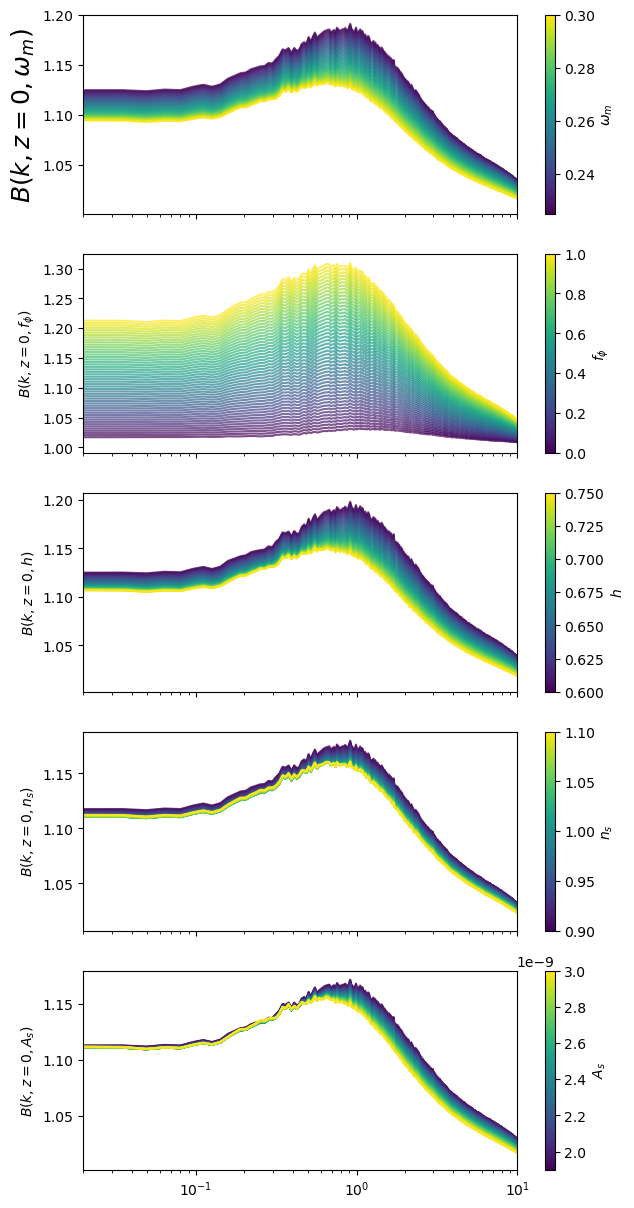

In [327]:
cmap = matplotlib.colormaps['viridis']

f, ax = plt.subplots(5, sharex=True, sharey=False,figsize=(7, 15))

frac1 = (theta_new1[0] - min(theta_new1[0]))/(max(theta_new1[0])-min(theta_new1[0]))
frac2 = (theta_new2[1] - min(theta_new2[1]))/(max(theta_new2[1])-min(theta_new2[1]))
frac3 = (theta_new3[2] - min(theta_new3[2]))/(max(theta_new3[2])-min(theta_new3[2]))
frac4 = (theta_new4[3] - min(theta_new4[3]))/(max(theta_new4[3])-min(theta_new4[3]))
frac5 = (theta_new5[4] - min(theta_new5[4]))/(max(theta_new5[4])-min(theta_new5[4]))

for sim_index in range(50):
    ax[0].plot(k_arr, Bk_new1[sim_index], color = cmap(frac1[sim_index]), alpha=0.7)
    ax[1].plot(k_arr, Bk_new2[sim_index], color = cmap(frac2[sim_index]), alpha=0.7)
    ax[2].plot(k_arr, Bk_new3[sim_index], color = cmap(frac3[sim_index]), alpha=0.7)
    ax[3].plot(k_arr, Bk_new4[sim_index], color = cmap(frac4[sim_index]), alpha=0.7)
    ax[4].plot(k_arr, Bk_new5[sim_index], color = cmap(frac5[sim_index]), alpha=0.7)
    #plt.plot(k_arr, Bk_arr[sim_index, 0, :], 'r', alpha=0.2)
    
ax[0].set_ylabel(r"$B(k,z=0,\omega_m)$", fontsize=18)
ax[1].set_ylabel(r"$B(k,z=0,f_\phi)$")
ax[2].set_ylabel(r"$B(k,z=0,h)$")
ax[3].set_ylabel(r"$B(k,z=0,n_s)$")
ax[4].set_ylabel(r"$B(k,z=0,A_s)$")
plt.xscale("log")

norm = matplotlib.colors.Normalize(vmin=min(theta_new1[0]), vmax=max(theta_new1[0]))
f.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax = ax[0], orientation='vertical', label=r'$\omega_m$')
norm = matplotlib.colors.Normalize(vmin=min(theta_new2[1]), vmax=max(theta_new2[1]))
f.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax = ax[1], orientation='vertical', label=r'$f_{\phi}$')
norm = matplotlib.colors.Normalize(vmin=min(theta_new3[2]), vmax=max(theta_new3[2]))
f.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax = ax[2], orientation='vertical', label=r'$h$')
norm = matplotlib.colors.Normalize(vmin=min(theta_new4[3]), vmax=max(theta_new4[3]))
f.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax = ax[3], orientation='vertical', label=r'$n_s$')
norm = matplotlib.colors.Normalize(vmin=min(theta_new5[4]), vmax=max(theta_new5[4]))
f.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax = ax[4], orientation='vertical', label=r'$A_s$')


ax[0].set_xlim(2e-2,1e1)
plt.show()

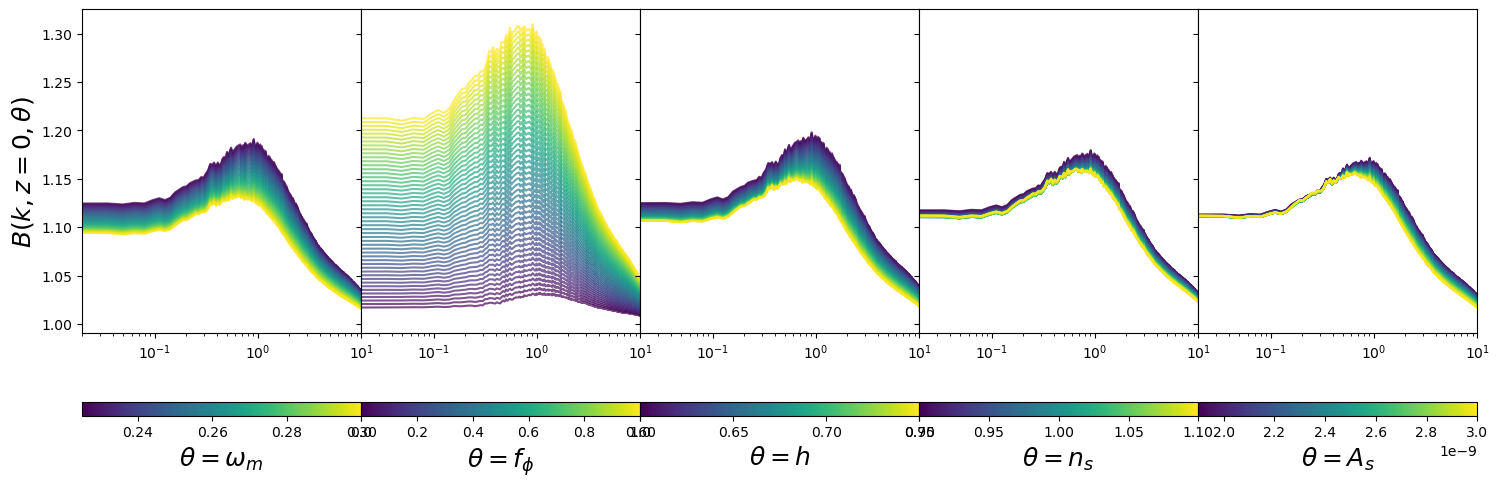

In [328]:
cmap = matplotlib.colormaps['viridis']

f, ax = plt.subplots(1,5, sharex=False, sharey=True,figsize=(18, 6))



frac1 = (theta_new1[0] - min(theta_new1[0]))/(max(theta_new1[0])-min(theta_new1[0]))
frac2 = (theta_new2[1] - min(theta_new2[1]))/(max(theta_new2[1])-min(theta_new2[1]))
frac3 = (theta_new3[2] - min(theta_new3[2]))/(max(theta_new3[2])-min(theta_new3[2]))
frac4 = (theta_new4[3] - min(theta_new4[3]))/(max(theta_new4[3])-min(theta_new4[3]))
frac5 = (theta_new5[4] - min(theta_new5[4]))/(max(theta_new5[4])-min(theta_new5[4]))

for sim_index in range(50):
    ax[0].plot(k_arr, Bk_new1[sim_index], color = cmap(frac1[sim_index]), alpha=0.7)
    ax[1].plot(k_arr, Bk_new2[sim_index], color = cmap(frac2[sim_index]), alpha=0.7)
    ax[2].plot(k_arr, Bk_new3[sim_index], color = cmap(frac3[sim_index]), alpha=0.7)
    ax[3].plot(k_arr, Bk_new4[sim_index], color = cmap(frac4[sim_index]), alpha=0.7)
    ax[4].plot(k_arr, Bk_new5[sim_index], color = cmap(frac5[sim_index]), alpha=0.7)
    #plt.plot(k_arr, Bk_arr[sim_index, 0, :], 'r', alpha=0.2)
    
ax[0].set_ylabel(r"$B(k,z=0,\theta)$", fontsize=18)


norm = matplotlib.colors.Normalize(vmin=min(theta_new1[0]), vmax=max(theta_new1[0]))
cbar = f.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax = ax[0], orientation='horizontal')
cbar.set_label(r'$\theta =\omega_m$', fontsize=18)

norm = matplotlib.colors.Normalize(vmin=min(theta_new2[1]), vmax=max(theta_new2[1]))
cbar = f.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax = ax[1], orientation='horizontal')
cbar.set_label(r'$\theta =f_{\phi}$', fontsize=18)

norm = matplotlib.colors.Normalize(vmin=min(theta_new3[2]), vmax=max(theta_new3[2]))
cbar = f.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax = ax[2], orientation='horizontal')
cbar.set_label(r'$\theta =h$', fontsize=18)

norm = matplotlib.colors.Normalize(vmin=min(theta_new4[3]), vmax=max(theta_new4[3]))
cbar = f.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax = ax[3], orientation='horizontal')
cbar.set_label(r'$\theta =n_s$', fontsize=18)

norm = matplotlib.colors.Normalize(vmin=min(theta_new5[4]), vmax=max(theta_new5[4]))
cbar = f.colorbar(matplotlib.cm.ScalarMappable(norm=norm, cmap=cmap), ax = ax[4], orientation='horizontal')
cbar.set_label(r'$\theta =A_s$', fontsize=18)


ax[0].set_xlim(2e-2,1e1)
ax[1].set_xlim(2e-2,1e1)
ax[2].set_xlim(2e-2,1e1)
ax[3].set_xlim(2e-2,1e1)
ax[4].set_xlim(2e-2,1e1)
ax[0].set_xscale("log")
ax[1].set_xscale("log")
ax[2].set_xscale("log")
ax[3].set_xscale("log")
ax[4].set_xscale("log")
plt.subplots_adjust(wspace=0)

#plt.savefig('GP_sensitivityanalysis.pdf' , bbox_inches='tight')

plt.show()